In [2]:
from pathlib import Path
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

clean = pd.read_csv(
    ROOT / "data" / "processed" / "sichuan_opera_cleaned.csv",
    encoding="utf-8-sig",
    dtype={"作品ID":"string"}
)

display(clean.head())

,序号,作品标题,类型,时长（分:秒）,duration_seconds,作品ID,来源链接,likes,shares,comments,互动采集日期,计数说明
0,1,百戏聚昆山，省川赴新程。 由四川省川剧院二级演员杨坤昊主演的《肖方杀船》将于9月24日 19...,视频,01:14,74.0,7688661826673839411,https://www.douyin.com/video/7688661826673839411,176.0,4.0,12.0,2026-09-24,NaN
1,2,《肖方杀船》中最负盛名的看点便是“藏刀”——将钢刀藏于身上，时隐时现，防不胜防。 刀不见影，...,视频,00:35,35.0,7688291532352392474,https://www.douyin.com/video/7688291532352392474,379.0,35.0,32.0,2026-09-24,NaN
2,3,省川《肖方杀船》即将亮相2026年戏曲百戏（昆山）盛典经典折子戏（绝技绝活）展演！ 汇中国百...,视频,01:14,74.0,7687895826277879081,https://www.douyin.com/video/7687895826277879081,59.0,NaN,3.0,2026-09-24,分享未显示数字
3,4,“川味儿老苏”和“吴越东坡”成都梦幻联动，川、越共品东坡千古风骨！ 9月10日，四川省川剧院...,视频,01:22,82.0,7684227973855087918,https://www.douyin.com/video/7684227973855087918,175.0,18.0,8.0,2026-09-24,NaN
4,5,“花果山前旌旗动，水帘洞中藏劲风。七十二变不相同，四方独尊孙悟空……” 00后文武小生梁浩龙...,视频,01:32,92.0,7683462866351017267,https://www.douyin.com/video/7683462866351017267,49.0,1.0,6.0,2026-09-24,NaN


In [10]:
# Select videos with valid durations.
duration = pd.to_numeric(
    clean["duration_seconds"], errors="coerce"
)

is_video = clean["类型"].astype("string").str.strip().eq("视频")

videos = clean.loc[
    is_video & duration.gt(0)
].copy()

videos["duration_seconds"] = duration.loc[videos.index]

# Stop for investigation if post IDs are missing or repeated.
assert videos["作品ID"].notna().all(), "Investigate missing post IDs."
assert not videos["作品ID"].duplicated().any(),(
    "Investigate repeated post IDs before comparing videos."
)

# Define duration groups.
videos["duration_group"] = pd.cut(
    videos["duration_seconds"],
    bins= [0,60,float("inf")],
    labels=["≤60 seconds", ">60 seconds"]
)

#Require all three interaction counts.
videos["total_interactions"] = videos[
    ["likes", "comments", "shares"]
].sum(axis=1, min_count=3)

#Summarise performance and data coverage.
summary = (
    videos.groupby("duration_group", observed=True)
    .agg(
        video_count=("作品ID","size"),
        likes_n=("likes","count"),
        median_likes=("likes","median"),
        comments_n=("comments","count"),
        median_comments=("comments","median"),
        shares_n=("shares","count"),
        median_shares=("shares","median"),
        total_interactions_n=("total_interactions","count"),
        median_total_interactions=("total_interactions","median")
    )
)
summary["share_coverage_percent"] = (
    summary["shares_n"] / summary["video_count"] * 100
).round(1)

display(summary)

,video_count,likes_n,median_likes,comments_n,median_comments,shares_n,median_shares,total_interactions_n,median_total_interactions,share_coverage_percent
duration_group,,,,,,,,,,
≤60 seconds,190,190,76.5,190,5.0,167,5.0,167,96.0,87.9
>60 seconds,226,226,83.0,226,6.0,209,6.0,209,106.0,92.5


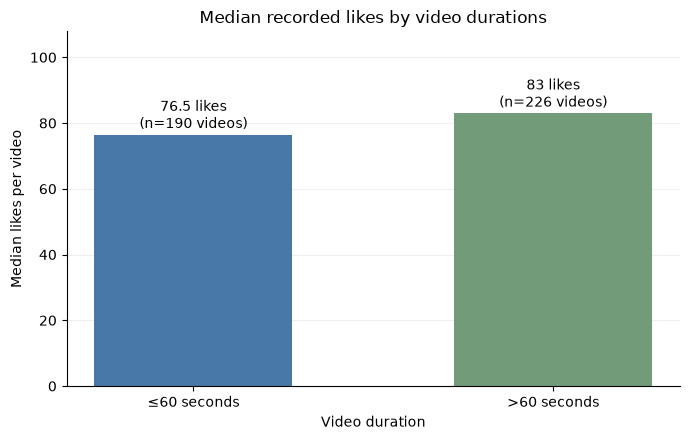

In [13]:
import matplotlib.pyplot as plt

# Use the summary table calculated above.
labels = summary.index.astype(str).tolist()
medians = summary["median_likes"].tolist()
sample_sizes = summary["likes_n"].tolist()

fig, ax = plt.subplots(figsize=(7, 4.5))

bars = ax.bar(
    labels,
    medians,
    color=["#4878A8", "#729B79"],
    width=0.55
)

# Show each median and the number of videos contributing to it.
for bar, median, n in zip(bars, medians, sample_sizes):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"{median:g} likes\n(n={n} videos)",
        ha="center",
        fontsize=10
    )

ax.set(
    title="Median recorded likes by video durations",
    xlabel="Video duration",
    ylabel="Median likes per video",
    ylim=(0, max(medians) * 1.3)
)

ax.spines[["top", "right"]].set_visible(False)
ax.set_axisbelow(True)
ax.grid(axis="y", alpha=0.2)

fig.tight_layout()
plt.show()

figure_folder = ROOT / "reports" / "figures"
figure_folder.mkdir(parents=True, exist_ok=True)

image_path = figure_folder / "median_likes_by_duration.png"

fig.savefig(image_path, dpi=200, bbox_inches="tight")

print("Saved to:", image_path)
print("File exists:", image_path.exists())